In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

folder_path = "/content/drive/MyDrive/MyDrive/cease_project/input_pdfs"

files = [f for f in os.listdir(folder_path) if f.endswith(".pdf")]

print("Files found:", files)

Files found: ['bw_doc_3.pdf', 'LOA2.pdf', 'LOA8.pdf', 'bw_doc_5.pdf', 'notice_2.pdf', 'LOA7.pdf', 'LOA6.pdf', 'bw_doc_4.pdf', 'LoA1.pdf', 'notice_1.pdf', 'LOA4.pdf', 'bw_doc_2.pdf', 'notice_3.pdf', 'LOA3.pdf', 'notice_4.pdf', 'LOA5.pdf', 'bw_doc_1.pdf', 'LOA9.pdf', 'notice_5.pdf']


In [3]:
file_paths = [os.path.join(folder_path, f) for f in files]

for path in file_paths:
    print(path)

/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/bw_doc_3.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LOA2.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LOA8.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/bw_doc_5.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/notice_2.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LOA7.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LOA6.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/bw_doc_4.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LoA1.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/notice_1.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LOA4.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/bw_doc_2.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/notice_3.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LOA3.pdf
/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/notice

In [4]:
!apt-get install -y tesseract-ocr
!apt-get install -y poppler-utils
!pip install pytesseract pdf2image pypdf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


In [5]:
import pytesseract
from pdf2image import convert_from_path
from pypdf import PdfReader
import re

In [6]:
def read_normal_pdf(file_path):
    text = ""
    try:
        reader = PdfReader(file_path)
        for page in reader.pages:
            if page.extract_text():
                text += page.extract_text()
    except:
        pass
    return text

In [7]:
def read_scanned_pdf(file_path):
    images = convert_from_path(file_path)

    text = ""
    for image in images:
        text += pytesseract.image_to_string(image, config="--psm 6") + "\n"

    return text

In [8]:
def clean_text(text):
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [9]:
def read_pdf_smart(file_path):
    print(f"Reading: {file_path}")

    # Step 1: Try normal extraction
    text = read_normal_pdf(file_path)

    # Step 2: Check if text is valid
    if text and len(text.strip()) > 50:
        print("✅ Used normal PDF reader")
        return clean_text(text)

    # Step 3: Fallback to OCR
    print("🔄 Falling back to OCR...")
    text = read_scanned_pdf(file_path)

    return clean_text(text)

In [10]:
for path in file_paths:
    print("\n======================")

    text = read_pdf_smart(path)

    if len(text) < 30:
        print("⚠️ No useful text found")
    else:
        print(text[:300])


Reading: /content/drive/MyDrive/MyDrive/cease_project/input_pdfs/bw_doc_3.pdf
🔄 Falling back to OCR...
Harrington Legal Counsel suumeerzoeseaon 9 Willow Bend, Suite 12 Document Production Unit Dat: Octobor 11, 2025 Request for Limited Document Production for Audit Our office represents a corporate client engaged in a routine compliance audit that necessitates limited access to historical account corr

Reading: /content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LOA2.pdf
✅ Used normal PDF reader
LAW OFFICES OF DONALD A. GREEN, APLC. 32 DWINELL ST UNIT 187,BUFFALO,CA Date: 7/2/2025 Account/Reference#: __________ _ To Whom It May Concern: I (we) have retained the services of LAW OFFICES OF DONALD A. GREEN, APLC to assist me in resolving my debt and have granted it this Limited Power of Attorn

Reading: /content/drive/MyDrive/MyDrive/cease_project/input_pdfs/LOA8.pdf
✅ Used normal PDF reader
DocoSign Envelope ID: AS3E6003-CAAD-4o3S-BOC8•FB390C4E'EFFA Exhibit C Authorization to Communi

In [11]:
import sqlite3

conn = sqlite3.connect("cease_system.db")
cursor = conn.cursor()

In [12]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS documents (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    document_name TEXT UNIQUE,
    processed_date TEXT,
    status TEXT,
    classification TEXT,
    confidence INTEGER
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS cease_requests (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    document_name TEXT,
    received_date TEXT,
    extracted_text TEXT,
    confidence INTEGER
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS audit_logs (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    document_name TEXT,
    classification TEXT,
    action_taken TEXT,
    timestamp TEXT,
    reason TEXT,
    confidence INTEGER
)
""")

conn.commit()

In [13]:
from datetime import datetime

def insert_document(doc_name, status, classification, confidence):
    try:
        cursor.execute(
            """
            INSERT INTO documents
            (document_name, processed_date, status, classification, confidence)
            VALUES (?, ?, ?, ?, ?)
            """,
            (doc_name, str(datetime.now()), status, classification, confidence)
        )
        conn.commit()

    except Exception as e:
        print(f"⚠️ Skipping duplicate: {doc_name}")

In [14]:
def insert_cease(doc_name, text, confidence):
    cursor.execute(
        """
        INSERT INTO cease_requests
        (document_name, received_date, extracted_text, confidence)
        VALUES (?, ?, ?, ?)
        """,
        (doc_name, str(datetime.now()), text, confidence)
    )
    conn.commit()

In [15]:
def insert_audit(doc_name, classification, action, reason, confidence):
    cursor.execute(
        """
        INSERT INTO audit_logs
        (document_name, classification, action_taken, timestamp, reason, confidence)
        VALUES (?, ?, ?, ?, ?, ?)
        """,
        (doc_name, classification, action, str(datetime.now()), reason, confidence)
    )
    conn.commit()

In [16]:
def add_column_if_not_exists(table, column_def):
    try:
        cursor.execute(f"ALTER TABLE {table} ADD COLUMN {column_def}")
    except Exception as e:
        print(f"Skipping: {column_def} already exists")

add_column_if_not_exists("audit_logs", "classification TEXT")
add_column_if_not_exists("audit_logs", "confidence INTEGER")

conn.commit()

Skipping: classification TEXT already exists
Skipping: confidence INTEGER already exists


In [17]:
cursor.execute("SELECT document_name, classification, confidence FROM documents")
rows = cursor.fetchall()

for row in rows:
    print(row)

In [18]:
!pip install groq

In [19]:
from groq import Groq
import json

client = Groq(api_key="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")

def build_prompt(text):
    return f"""
You are a strict legal document classification system.

Your task is to classify the document into EXACTLY ONE category:

1. Cease
- Explicit instruction to STOP communication
- Examples: "cease communication", "stop contacting", "no further contact"

2. Irrelevant
- Administrative or informational documents
- Examples: power of attorney, account access, authorization letters
- ANY document that does NOT clearly request stopping communication

3. Uncertain
- Indirect, temporary, or unclear language
- Examples:
  - "temporarily pause communication"
  - "hold communication"
  - "await clarification before further contact"
  - "review before continuing communication"

CRITICAL RULES:
- "pause", "temporarily stop", "hold communication" → ALWAYS Uncertain
- Only strong, permanent stop → Cease
- If not clearly Cease → do NOT classify as Cease

Also provide a confidence score (0–100):
- 90–100 → very confident
- 70–89 → confident
- 50–69 → moderate
- below 50 → low confidence

Document:
{text[:3000]}

Return ONLY JSON:
{{
  "classification": "Cease / Irrelevant / Uncertain",
  "confidence": number,
  "reason": "short explanation"
}}
"""

In [20]:
def clean_json_output(output):
    output = output.strip()

    # remove ```json or ``` wrappers
    if output.startswith("```"):
        output = output.replace("```json", "").replace("```", "").strip()

    return output

In [21]:
def classify_with_groq(text):

    print("\n🚀 classify_with_groq CALLED")
    prompt = build_prompt(text)

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}]
    )

    output = response.choices[0].message.content.strip()

    print("\n🔹 RAW MODEL OUTPUT:")
    print(output)

    # ✅ CLEAN OUTPUT
    output = clean_json_output(output)

    try:
        result = json.loads(output)
    except:
        result = {
            "classification": "Uncertain",
            "reason": output
        }

    return result

In [22]:
def normalize_classification(label):
    label = label.lower()

    if "cease" in label:
        return "Cease"
    elif "irrelevant" in label:
        return "Irrelevant"
    else:
        return "Uncertain"

In [23]:
def classify_document(text):

    print("\n📌 classify_document CALLED")  # 👈 debug

    # Otherwise use LLM
    result = classify_with_groq(text)

    classification = normalize_classification(
        result.get("classification", "Uncertain")
    )

    reason = result.get("reason", "")
    confidence = result.get("confidence", 50)

    print("\n✅ FINAL RESULT:")
    print("Classification:", classification)
    print("Confidence:", confidence)
    print("Reason:", reason)

    return classification, reason, confidence

In [24]:
def archive_document(doc_name):
    with open("archive.txt", "a") as f:
        f.write(f"{doc_name}\n")

In [25]:
def human_review():
    decision = input("Enter decision (Cease / Irrelevant): ")
    return decision

In [26]:
def process_document(file_path):
    import os

    doc_name = os.path.basename(file_path)

    try:
        # Step 1: Read PDF
        text = read_pdf_smart(file_path)

        if len(text) < 30:
            insert_document(doc_name, "failed")
            insert_audit(doc_name, "Uncertain", "Skipped", "No readable text")
            return

        # Step 2: Classify
        classification, reason = classify_document(text)

        print(f"Classification: {classification}")

        # Step 3: Route based on classification

        if classification == "Cease":
            insert_cease(doc_name, text)
            insert_document(doc_name, "processed")
            insert_audit(doc_name, classification, "Stored in DB", reason)

        elif classification == "Irrelevant":
            archive_document(doc_name)
            insert_document(doc_name, "processed")
            insert_audit(doc_name, classification, "Archived", reason)

        else:  # Uncertain
            print("⚠️ Needs human review")
            decision = human_review()

            if decision == "Cease":
                insert_cease(doc_name, text)
                action = "HITL → Stored"
            else:
                archive_document(doc_name)
                action = "HITL → Archived"

            insert_document(doc_name, "processed")
            insert_audit(doc_name, "Uncertain", action, reason)

    except Exception as e:
        print("Error:", e)
        insert_document(doc_name, "failed")
        insert_audit(doc_name, "Error", "Failed", str(e))

In [27]:
from typing import TypedDict

class State(TypedDict, total=False):
    document_name: str
    file_path: str
    text: str
    classification: str
    reason: str
    confidence: int

In [28]:
def loader_agent(state: State):
    text = read_pdf_smart(state["file_path"])

    return {
        **state,
        "text": text
    }

In [29]:
def classification_agent(state: State):

    print("\n🧠 classification_agent CALLED")

    text = state["text"]

    print("Text length:", len(text))

    if len(text) < 30:
        state["classification"] = "Uncertain"
        state["reason"] = "No readable content"
        state["confidence"] = 0
        return state

    classification, reason, confidence = classify_document(text)

    return {
        **state,
        "classification": classification,
        "reason": reason,
        "confidence": confidence
    }

In [30]:
def cease_agent(state: State):
    insert_cease(
        state["document_name"],
        state["text"],
        state["confidence"]
    )

    insert_document(
        state["document_name"],
        "processed",
        state["classification"],
        state["confidence"]
    )

    insert_audit(
        state["document_name"],
        state["classification"],
        "Stored in DB",
        state["reason"],
        state["confidence"]
    )

    return {**state}

In [31]:
def archive_agent(state: State):
    print("\n🔍 STATE INSIDE ARCHIVE:", state.keys())
    archive_document(state["document_name"])

    insert_document(
        state["document_name"],
        "processed",
        state["classification"],
        state["confidence"]
    )

    insert_audit(
        state["document_name"],
        state["classification"],
        "Archived",
        state["reason"],
        state["confidence"]
    )

    print("STATE:", state)

    return {**state}

In [32]:
def hitl_agent(state: State):
    decision = input("Enter decision (Cease / Irrelevant): ")

    if decision == "Cease":
        insert_cease(
            state["document_name"],
            state["text"],
            state["confidence"]
        )
        action = "HITL → Stored"
    else:
        archive_document(state["document_name"])
        action = "HITL → Archived"

    insert_document(
        state["document_name"],
        "processed",
        decision,
        state["confidence"]
    )

    insert_audit(
        state["document_name"],
        "Uncertain",
        action,
        state["reason"],
        state["confidence"]
    )

    return {**state}

In [33]:
def router(state: State):
    if state["classification"] == "Cease":
        return "cease"
    elif state["classification"] == "Irrelevant":
        return "archive"
    else:
        return "hitl"

In [34]:
from langgraph.graph import StateGraph

builder = StateGraph(State)

In [35]:
builder.add_node("loader", loader_agent)
builder.add_node("classify", classification_agent)
builder.add_node("cease", cease_agent)
builder.add_node("archive", archive_agent)
builder.add_node("hitl", hitl_agent)

In [36]:
builder.set_entry_point("loader")

In [37]:
builder.add_edge("loader", "classify")

In [38]:
builder.add_conditional_edges(
    "classify",
    router,
    {
        "cease": "cease",
        "archive": "archive",
        "hitl": "hitl"
    }
)

In [39]:
graph = builder.compile()

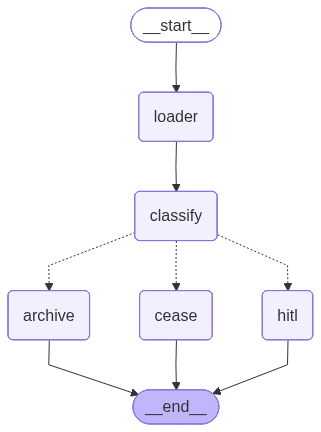

In [40]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("⚠️ Graph visualization not available:", e)

In [41]:
import time
import os
import traceback  # 👈 IMPORTANT

failed_files = []
summary = {"Cease": 0, "Irrelevant": 0, "Uncertain": 0}

for path in file_paths:
    try:
        print("\n====================")
        print("Processing:", path)

        doc_name = os.path.basename(path)

        input_data = {
            "document_name": doc_name,
            "file_path": path
        }

        result = graph.invoke(input_data)

        classification = result.get("classification", "Uncertain")

        # update summary
        if classification in summary:
            summary[classification] += 1
        else:
            summary["Uncertain"] += 1

        time.sleep(2)

    except Exception as e:
        print("\n❌ ERROR OCCURRED")
        print("File:", path)
        print("Error message:", str(e))

        # 👇 Full traceback (VERY IMPORTANT)
        traceback.print_exc()

        failed_files.append({
            "file": path,
            "error": str(e)
        })

# 🔥 FINAL OUTPUT
print("\n📊 SUMMARY:")
print(summary)

print("\n❌ Failed files:")
for f in failed_files:
    print(f)


Processing: /content/drive/MyDrive/MyDrive/cease_project/input_pdfs/bw_doc_3.pdf
Reading: /content/drive/MyDrive/MyDrive/cease_project/input_pdfs/bw_doc_3.pdf
🔄 Falling back to OCR...

🧠 classification_agent CALLED
Text length: 1124

📌 classify_document CALLED

🚀 classify_with_groq CALLED

🔹 RAW MODEL OUTPUT:
{
  "classification": "Irrelevant",
  "confidence": 100,
  "reason": "The document is a request for document production for an audit, which is an administrative task and does not contain any instruction to stop communication."
}

✅ FINAL RESULT:
Classification: Irrelevant
Confidence: 100
Reason: The document is a request for document production for an audit, which is an administrative task and does not contain any instruction to stop communication.

🔍 STATE INSIDE ARCHIVE: dict_keys(['document_name', 'file_path', 'text', 'classification', 'reason', 'confidence'])
STATE: {'document_name': 'bw_doc_3.pdf', 'file_path': '/content/drive/MyDrive/MyDrive/cease_project/input_pdfs/bw_doc_

In [42]:
cursor.execute("SELECT COUNT(*) FROM documents")
print("Total processed:", cursor.fetchone()[0])

cursor.execute("SELECT COUNT(*) FROM cease_requests")
print("Cease detected:", cursor.fetchone()[0])

cursor.execute("""
SELECT classification, AVG(confidence)
FROM audit_logs
GROUP BY classification
""")

print(cursor.fetchall())

Total processed: 19
Cease detected: 13
[('Cease', 99.375), ('Irrelevant', 100.0), ('Uncertain', 88.0)]


In [43]:
!pip install pandas

In [44]:
import pandas as pd

df = pd.read_sql_query("SELECT * FROM documents", conn)
df

,id,document_name,processed_date,status,classification,confidence
0,60,bw_doc_3.pdf,2026-03-23 07:31:20.018704,processed,Irrelevant,100
1,61,LOA2.pdf,2026-03-23 07:31:22.444635,processed,Cease,100
2,62,LOA8.pdf,2026-03-23 07:31:25.485444,processed,Cease,95
3,63,bw_doc_5.pdf,2026-03-23 07:31:34.080005,processed,Irrelevant,100
4,64,notice_2.pdf,2026-03-23 07:31:49.226028,processed,Cease,90
5,65,LOA7.pdf,2026-03-23 07:31:52.604674,processed,Cease,100
6,66,LOA6.pdf,2026-03-23 07:31:55.380231,processed,Cease,100
7,67,bw_doc_4.pdf,2026-03-23 07:32:02.538995,processed,Irrelevant,100
8,68,LoA1.pdf,2026-03-23 07:32:04.836686,processed,Cease,100
9,69,notice_1.pdf,2026-03-23 07:32:27.780940,processed,Cease,90


In [45]:
df = pd.read_sql_query(
    "SELECT document_name, classification, confidence FROM documents WHERE classification='Cease'",
    conn
)
df

,document_name,classification,confidence
0,LOA2.pdf,Cease,100
1,LOA8.pdf,Cease,95
2,notice_2.pdf,Cease,90
3,LOA7.pdf,Cease,100
4,LOA6.pdf,Cease,100
5,LoA1.pdf,Cease,100
6,notice_1.pdf,Cease,90
7,LOA4.pdf,Cease,100
8,notice_3.pdf,Cease,90
9,LOA3.pdf,Cease,100


In [46]:
df = pd.read_sql_query("SELECT * FROM audit_logs", conn)
df

,id,document_name,classification,action_taken,timestamp,reason,confidence
0,60,bw_doc_3.pdf,Irrelevant,Archived,2026-03-23 07:31:20.042874,The document is a request for document product...,100
1,61,LOA2.pdf,Cease,Stored in DB,2026-03-23 07:31:22.457664,Explicit instruction to stop communication wit...,100
2,62,LOA8.pdf,Cease,Stored in DB,2026-03-23 07:31:25.492630,The document contains the phrase 'cease and de...,95
3,63,bw_doc_5.pdf,Irrelevant,Archived,2026-03-23 07:31:34.089145,The document is an administrative notification...,100
4,64,notice_2.pdf,Uncertain,HITL → Stored,2026-03-23 07:31:49.234542,The document requests a 'temporary suspension'...,90
5,65,LOA7.pdf,Cease,Stored in DB,2026-03-23 07:31:52.612923,The document contains the explicit instruction...,100
6,66,LOA6.pdf,Cease,Stored in DB,2026-03-23 07:31:55.388080,Explicit instruction to stop all communications.,100
7,67,bw_doc_4.pdf,Irrelevant,Archived,2026-03-23 07:32:02.547213,The document is an administrative request for ...,100
8,68,LoA1.pdf,Cease,Stored in DB,2026-03-23 07:32:04.843150,Explicit instruction to cease and desist all c...,100
9,69,notice_1.pdf,Uncertain,HITL → Stored,2026-03-23 07:32:27.789132,The document requests a 'stop to specific outr...,90


In [47]:
df = pd.read_sql_query("""
SELECT classification, COUNT(*) as count
FROM documents
GROUP BY classification
""", conn)

df

,classification,count
0,Cease,13
1,Irrelevant,6


In [48]:
df = pd.read_sql_query("""
SELECT classification, AVG(confidence) as avg_confidence
FROM documents
GROUP BY classification
""", conn)

df

,classification,avg_confidence
0,Cease,95.0
1,Irrelevant,100.0


In [49]:
df = pd.read_sql_query(
    "SELECT document_name, action_taken, reason FROM audit_logs WHERE action_taken='HITL → Stored'",
    conn
)
df

,document_name,action_taken,reason
0,notice_2.pdf,HITL → Stored,The document requests a 'temporary suspension'...
1,notice_1.pdf,HITL → Stored,The document requests a 'stop to specific outr...
2,notice_3.pdf,HITL → Stored,The document requests an 'immediate pause' in ...
3,notice_4.pdf,HITL → Stored,The document asks to 'avoid initiating further...
4,notice_5.pdf,HITL → Stored,The document requests restraint in targeted co...
